In [1]:
!pip install tf-levenberg-marquardt 

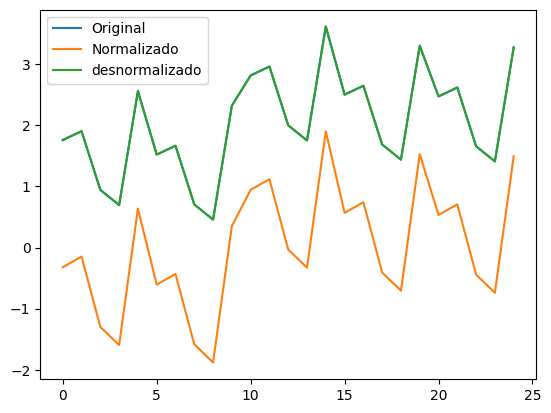

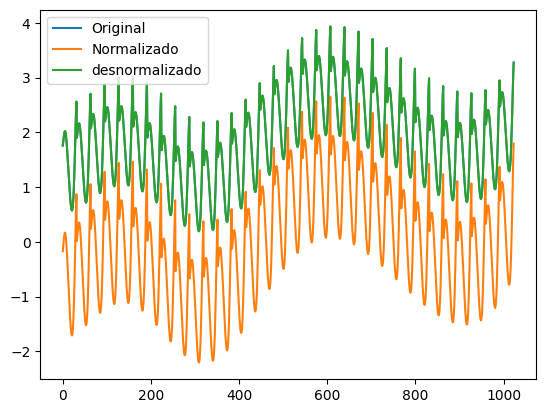

In [2]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

scaler = StandardScaler()
out_scaler = StandardScaler()

def function(grid):
    x = np.linspace(0, 1, grid)
    y = np.linspace(0, 1, grid)
    x, y = np.meshgrid(x, y)
    z = 1.3356 * (1.5 * (1 - x))+np.exp(2 * x - 1) * np.sin(3 * np.pi * (x - 0.6)**2)+np.exp(3*(y - 0.5)) * np.sin(4 * np.pi * (y - 0.9)**2)
    return x, y, z

def create_dataframe(grid):
   x, y, z = function(grid)
   data = {'X': x.flatten(), 'Y': y.flatten(), 'Z': z.flatten()}
   df = pd.DataFrame(data)
   return df

def show_norm(df, label="function", plot=False):
    df_norm = pd.DataFrame(scaler.fit_transform(df), columns=df.columns)
    df_denorm = pd.DataFrame(scaler.inverse_transform(df_norm), columns=df_norm.columns)

    if (plot):
        df.plot(title=f"{label}: Original data")
        df_norm.plot(title=f"{label}: Normalized data")
        df_denorm.plot(title=f"{label}: Denormalized data")
    return (df_norm)


def test_out_scaler(df):
    out = df["Z"].values.reshape(-1, 1)  
    plt.plot(out, label='Original')
    out_scaler.fit(out)
    norm = out_scaler.transform(out)
    plt.plot(norm, label='Normalizado')
    plt.plot(out_scaler.inverse_transform(norm), label='desnormalizado')
    plt.legend()
    plt.show()


df_25 = create_dataframe(grid=5)
df_25_norm = show_norm(df_25)
test_out_scaler(df_25)

df_1000 = create_dataframe(grid=32)
df_1000_norm = show_norm(df_1000)
test_out_scaler(df_1000)



In [3]:
def split_df(df):
    _input = np.vstack([df['X'], df['Y']]).T
    _output = np.array(df['Z'])
    return (_input, _output)

In [4]:
import tensorflow as tf
import numpy as np
from keras import regularizers
from keras import initializers
import tf_levenberg_marquardt as lm

# layers, neurons
class ShuffleArchitecture:
    def __init__(self, input_size, hidden_sizes, output_size, act_h, act_o, param_reg):
        self.input_size = input_size
        self.hidden_sizes = hidden_sizes
        self.output_size = output_size
        self.act_h = act_h
        self.act_o = act_o
        self.regularizer = regularizers.L2(param_reg)
        self.initializer = initializers.RandomUniform(minval=-0.5, maxval=0.5, seed=np.random.randint(1, 10000))

    def compute_k(self):
        total_parameters = 0
        for layer in self.model.layers:
            weights = layer.get_weights()
            if len(weights) > 0:  
                for w in weights:
                    total_parameters += np.prod(w.shape)
        return total_parameters
        
    def set_architecture(self):
        self.model = tf.keras.Sequential()
        self.model.add(tf.keras.layers.Dense(self.hidden_sizes[0],
                        input_shape=(self.input_size,),
                        activation=self.act_h,
                        kernel_regularizer=self.regularizer,
                        kernel_initializer=self.initializer,                        
                        ))  # input layer

        for size in self.hidden_sizes[1:]:  # hidden layers
            self.model.add(tf.keras.layers.Dense(size,
                            activation=self.act_h,
                            kernel_regularizer=self.regularizer,
                            kernel_initializer=self.initializer,  
                        ))

        self.model.add(tf.keras.layers.Dense(self.output_size,
                        activation=self.act_o,
                        kernel_regularizer=self.regularizer,
                        kernel_initializer=self.initializer,  
                        ))  # output layer

    def create_model(self, _learning_rate):
        mse_loss = lm.loss.MeanSquaredError()

        self.model.compile(
            optimizer=tf.keras.optimizers.Adam(learning_rate=_learning_rate),
            loss=tf.keras.losses.MeanSquaredError(),
        )
        self.lm_model = lm.model.ModelWrapper(
            tf.keras.models.clone_model(self.model)
        )
        self.lm_model.compile(
            optimizer=tf.keras.optimizers.SGD(learning_rate=_learning_rate),
             loss=lm.loss.MeanSquaredError()
        )
        return self.lm_model


2025-06-12 11:40:34.935877: I external/local_tsl/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2025-06-12 11:40:35.637357: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-06-12 11:40:35.637473: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-06-12 11:40:35.752431: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-06-12 11:40:35.970453: I external/local_tsl/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2025-06-12 11:40:35.972760: I tensorflow/core/platform/cpu_feature_guard.cc:1

In [5]:
from sklearn.model_selection import train_test_split
from keras.callbacks import EarlyStopping
from sklearn.metrics import r2_score, mean_squared_error, root_mean_squared_error, mean_absolute_percentage_error 

class TrainWithSmallDataset:
    def __init__(self, batch_size=1000):
        self.batch_size = batch_size
        self.betters = []
        self.k = 0

    def create_dataset(self, input, output):
      input = tf.expand_dims(tf.cast(input, tf.float32), axis=-1)
      output = tf.expand_dims(tf.cast(output, tf.float32), axis=-1)
      dataset = tf.data.Dataset.from_tensor_slices((input, output))
      dataset = dataset.shuffle(len(input))
      dataset = dataset.batch(self.batch_size).cache()
      dataset = dataset.prefetch(tf.data.experimental.AUTOTUNE)
      return (dataset, input, output)

    def split_dataset(self, input, output, sup_input, sup_output):
      input_train, input_vt, output_train, output_vt = train_test_split(input, output, test_size=0.3, shuffle = True)
      input_val, input_test, output_val, output_test = train_test_split(input_vt, output_vt, test_size=0.5, shuffle = True)

      self.train_dataset, self.train_input, self.train_output = self.create_dataset(input_train, output_train)
      self.val_dataset, self.val_input, self.val_output = self.create_dataset(input_val, output_val)
      self.test_dataset, self.test_input, self.test_output = self.create_dataset(input_test, output_test)
      self.vt_dataset, self.vt_input, self.vt_output = self.create_dataset(input_vt, output_vt)
      self.sup_dataset, self.sup_input, self.sup_output = self.create_dataset(sup_input, sup_output)
      self.dataset, self.input, self.output = self.create_dataset(input, output)

      self._data = (input, output)
      self._train = (input_train, output_train)
      self._vt = (input_vt, output_vt)
      self._val = (input_val, output_val)
      self._test = (input_test, output_test)
      self._sup = (sup_input, sup_output)
 
    def train_using_lm(self, train_dataset, epochs=1000):
      early_stopping_monitor = EarlyStopping(monitor='val_loss',
                                              patience=6,
                                              restore_best_weights=True)

      self.results = self.lm_model.fit(train_dataset,
                                            epochs=epochs,
                                            validation_data=self.val_dataset,
                                            callbacks=[early_stopping_monitor],
                                            verbose=0)
      print ("Stopped at epoch: ", early_stopping_monitor.stopped_epoch)
    
    def get_new_metrics(self, orig, pred, r2, mse):
      n = len(orig) # N: quantidade de saidas
      k = self.k
      waste = (orig.flatten() - pred.flatten())

      mape = mean_absolute_percentage_error(orig, pred)  
      r2_adj = 1 - (((n - 1)/(n - k - 1)) * (1 - r2))
      rsd = np.sqrt(np.sum(waste ** 2) / (n - 2))
      rmse = root_mean_squared_error(orig, pred)          
      aic = (-2 * np.log(mse)) + (2 * k)
      bic = (-2 * np.log(mse)) + (k * np.log(n))
      return (mape, r2_adj, rsd, rmse, aic, bic)
      

    def get_metrics(self):
          # Calculando a saida com os dados normalizados
          pred = self.lm_model.predict(self.input).flatten()
          test_pred = self.lm_model.predict(self.test_input).flatten()
          val_pred = self.lm_model.predict(self.val_input).flatten()
          vt_pred = self.lm_model.predict(self.vt_input).flatten()
          sup_pred = self.lm_model.predict(self.sup_input).flatten()

          # Calculando as metricas com a saida desnormalizada
          pred_denorm = out_scaler.inverse_transform(pred.reshape(-1, 1))
          test_pred_denorm = out_scaler.inverse_transform(test_pred.reshape(-1, 1))
          val_pred_denorm = out_scaler.inverse_transform(val_pred.reshape(-1, 1))
          vt_pred_denorm = out_scaler.inverse_transform(vt_pred.reshape(-1, 1))
          sup_pred_denorm = out_scaler.inverse_transform(sup_pred.reshape(-1, 1))

          out_denorm = out_scaler.inverse_transform(self._data[1].reshape(-1, 1))
          test_denorm = out_scaler.inverse_transform(self._test[1].reshape(-1, 1))
          val_denorm = out_scaler.inverse_transform(self._val[1].reshape(-1, 1))
          vt_denorm = out_scaler.inverse_transform(self._vt[1].reshape(-1, 1))    
          sup_denorm = out_scaler.inverse_transform(self._sup[1].reshape(-1, 1))

          r2 = r2_score(out_denorm, pred_denorm)
          r2_test = r2_score(test_denorm, test_pred_denorm)
          r2_val = r2_score(val_denorm, val_pred_denorm)
          r2_vt = r2_score(vt_denorm,  vt_pred_denorm)
          r2_sup = r2_score(sup_denorm,  sup_pred_denorm)

          mse = mean_squared_error(out_denorm, pred_denorm)
          mse_test = mean_squared_error(test_denorm, test_pred_denorm)
          mse_val = mean_squared_error(val_denorm, val_pred_denorm)
          mse_vt = mean_squared_error(vt_denorm,  vt_pred_denorm)
          mse_sup = mean_squared_error(sup_denorm,  sup_pred_denorm)
          
          mape, r2_adj, rsd, rmse, aic, bic = self.get_new_metrics(out_denorm, pred_denorm, r2, mse)
          metrics = {
                          'r2': r2,
                          'r2_sup': r2_sup,
                          'r2_test': r2_test,
                          'r2_val': r2_val,
                          'r2_vt': r2_vt,
                          'mse': mse,
                          'mse_sup': mse_sup,
                          'mse_test': mse_test,
                          'mse_val': mse_val,
                          'mse_vt': mse_vt,
                          'mape': mape,
                          'rmse': rmse,
                          'r2_adj': r2_adj,
                          'rsd': rsd,
                          'aic': aic,
                          'bic': bic
                          }

          return metrics

In [6]:
import pickle
from itertools import product

class Tester:
  def __init__(self, run_times=500, dataset_run_times=10):
    self.run_times = run_times
    self.better_metrics = {}
    self.dataset_run_times = dataset_run_times
    self.input_25, self.output_25 = split_df(df_25_norm)
    self.input_1000, self.output_1000 = split_df(df_1000_norm)
  
  def setArchitecure(self, trainer, _hidden_sizes, _pg, _lr):
    shuffler = ShuffleArchitecture(input_size=2,
                                    hidden_sizes=_hidden_sizes,
                                    output_size=1,
                                    act_h='tanh',
                                    act_o='linear',
                                    param_reg=_pg)
    shuffler.set_architecture()    
    trainer.lm_model = shuffler.create_model(_lr)
    trainer.k = shuffler.compute_k()

  def Train(self, trainer, epochs=1000):
    trainer.train_using_lm(trainer.train_dataset, epochs=epochs)
    return(trainer.get_metrics(), trainer.lm_model)

  def SaveModelWeights(self, model, fileName):
    path = f"content/models/{fileName}.keras"
    open(path,'w').close()
    model.save_weights(path)

  def SaveDataset(self, trainer, fileName):
    path = f"content/dataset/{fileName}.pkl" 
    with open(path, 'wb') as f:
      pickle.dump((trainer._data, trainer._train, trainer._vt, trainer._val, trainer._test), f)
      
  def LoopWeights(self, sort_by, boundarie, trainer, idx):
    better_model = 0
    save = False

    for i in range(self.run_times):
      print (f"+++++++++++ [{idx}] | {i + 1} ++++++++++++++++++")
      metrics, model = self.Train(trainer)
      if (metrics[sort_by] <= boundarie): # should be >= to acsending metrics
        fileName = f"model_{idx}_{better_model}"
        self.SaveModelWeights(model, fileName)
        self.better_metrics[fileName] = metrics
        better_model += 1
        save = True
    return(save)

  def Loop(self, sort_by, boundarie, hidden_sizes, regularizers, learning_rate):
    trainer = TrainWithSmallDataset()

    for count, (hidden_size, reg, lr) in enumerate(product(hidden_sizes, regularizers, learning_rate), start=1):
      header =  f"Hidden Size={hidden_size}, regularizer={reg}, learning_rate={lr}"
      print(f"Testando combinacao{count}: {header}")
      self.setArchitecure(trainer, hidden_size, reg, lr)
      for j in range(self.dataset_run_times):
        trainer.split_dataset(self.input_25, self.output_25, self.input_1000, self.output_1000)
        if (self.LoopWeights(sort_by, boundarie, trainer, f"{count}_{j}") == True):
          self.SaveDataset(trainer, f"dataset_{count}_{j}")
          self.DisplayBetterResults('mse_sup', header, f"{count}_{j}")
        self.better_metrics = {}

  def DisplayBetterResults(self, sort_by, header, dataset=0):
    df = pd.DataFrame.from_dict(self.better_metrics, orient='index')
    df = df.sort_values([sort_by])
    display(df)
    path = f'content/results/metrics_{dataset}'
    df.to_excel(f"{path}.xlsx", index=True)
    print(f"DataFrame salvo em {path}")
    with open(f"{path}.txt", 'w') as arquivo:
      arquivo.write(header)

# Treinando com 25 dados


In [7]:
tester = Tester(run_times=25, dataset_run_times=10)
tester.Loop(sort_by='mse',
            boundarie = 0.6,
            hidden_sizes = [[5, 4], [6, 6], [7, 7], [6, 4], [4, 5], [7, 6], [7, 4]],
            regularizers=[0.5, 0.03],
            learning_rate=[0.1, 0.05])

Testando combinacao1: Hidden Size=[5, 4], regularizer=0.5, learning_rate=0.1


+++++++++++ [1_0] | 1 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 2ms/step
+++++++++++ [1_0] | 2 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 3ms/step
+++++++++++ [1_0] | 3 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 2ms/step
+++++++++++ [1_0] | 4 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 2ms/step
+++++++++++ [1_0] | 5 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 4ms/step
+++++++++++ [1_0] | 6 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 2ms/step
+++++++++++ [1_0] | 7 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 2ms/step
+++++++++++ [1_0] | 8 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 2ms/step
+++++++++++ [1_0] | 9 ++++++++++++++++++
Stopped at epoch:  6
32/32 [===========

,r2,r2_sup,r2_test,r2_val,r2_vt,mse,mse_sup,mse_test,mse_val,mse_vt,mape,rmse,r2_adj,rsd,aic,bic
model_1_0_0,0.613222,0.429990,0.671250,-0.443702,0.559256,0.229608,0.338382,0.316203,0.314314,0.315259,0.301782,0.479175,1.464134,0.499574,90.942761,144.573298
model_1_0_1,0.510448,0.203763,0.927474,-5.643285,-0.059781,0.290619,0.472680,0.069759,1.446337,0.758048,0.240242,0.539091,1.587463,0.562042,90.471482,144.102018
model_1_0_2,0.501263,0.174902,0.955472,-6.176836,-0.122155,0.296072,0.489814,0.042829,1.562499,0.802664,0.224637,0.544125,1.598485,0.567290,90.434305,144.064841
model_1_0_3,0.498257,0.154654,0.970863,-6.508085,-0.162219,0.297856,0.501834,0.028025,1.634616,0.831321,0.210428,0.545762,1.602091,0.568996,90.422289,144.052825
model_1_0_4,0.502195,0.144002,0.975758,-6.637243,-0.178584,0.295519,0.508158,0.023317,1.662736,0.843026,0.198671,0.543616,1.597367,0.566759,90.438045,144.068582
model_1_0_5,0.510265,0.139820,0.973531,-6.631498,-0.179207,0.290728,0.510640,0.025459,1.661485,0.843472,0.188831,0.539192,1.587682,0.562146,90.470735,144.101271
model_1_0_8,0.538024,0.138888,0.948837,-6.330406,-0.149987,0.274249,0.511193,0.049210,1.595933,0.822571,0.175227,0.523688,1.554371,0.545982,90.587440,144.217977
model_1_0_7,0.529368,0.138886,0.958478,-6.445999,-0.161097,0.279388,0.511194,0.039938,1.621099,0.830518,0.179451,0.528571,1.564759,0.551074,90.550310,144.180846
model_1_0_6,0.519840,0.138815,0.967117,-6.554278,-0.171767,0.285043,0.511237,0.031628,1.644673,0.838151,0.183994,0.533895,1.576191,0.556624,90.510227,144.140764
model_1_0_9,0.545454,0.138305,0.938924,-6.220269,-0.139891,0.269838,0.511539,0.058745,1.571955,0.815350,0.171342,0.519460,1.545455,0.541574,90.619865,144.250401


DataFrame salvo em content/results/metrics_1_0
+++++++++++ [1_1] | 1 ++++++++++++++++++
Stopped at epoch:  14
32/32 [==============================] - 0s 2ms/step
+++++++++++ [1_1] | 2 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 2ms/step
+++++++++++ [1_1] | 3 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 2ms/step
+++++++++++ [1_1] | 4 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 2ms/step
+++++++++++ [1_1] | 5 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 2ms/step
+++++++++++ [1_1] | 6 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 3ms/step
+++++++++++ [1_1] | 7 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 2ms/step
+++++++++++ [1_1] | 8 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 2ms/step
+++++++++++ [1_1] | 9 ++++++++++

,r2,r2_sup,r2_test,r2_val,r2_vt,mse,mse_sup,mse_test,mse_val,mse_vt,mape,rmse,r2_adj,rsd,aic,bic
model_1_1_24,0.895785,0.529864,0.893563,-0.539482,0.541959,0.061866,0.279093,0.065062,0.320773,0.192917,0.049707,0.248729,1.125057,0.259318,93.565561,147.196097
model_1_1_23,0.895236,0.529722,0.891016,-0.540864,0.539769,0.062192,0.279177,0.066618,0.321061,0.193840,0.050366,0.249384,1.125717,0.260001,93.555046,147.185583
model_1_1_22,0.894594,0.529517,0.888100,-0.542600,0.537223,0.062574,0.279299,0.068401,0.321423,0.194912,0.051097,0.250147,1.126487,0.260796,93.542826,147.173362
model_1_1_21,0.893840,0.529228,0.884754,-0.544801,0.534251,0.063021,0.279471,0.070446,0.321881,0.196164,0.051906,0.251040,1.127392,0.261727,93.528572,147.159108
model_1_1_20,0.892953,0.528829,0.880911,-0.547589,0.530773,0.063548,0.279708,0.072795,0.322462,0.197629,0.052800,0.252087,1.128456,0.262818,93.511930,147.142466
model_1_1_19,0.891906,0.528287,0.876491,-0.551127,0.526690,0.064169,0.280029,0.075497,0.323199,0.199348,0.053786,0.253316,1.129712,0.264100,93.492467,147.123003
model_1_1_18,0.890668,0.527559,0.871408,-0.555637,0.521886,0.064904,0.280461,0.078604,0.324139,0.201371,0.054871,0.254763,1.131198,0.265609,93.469685,147.100221
model_1_1_17,0.889201,0.526592,0.865568,-0.561387,0.516226,0.065775,0.281035,0.082174,0.325337,0.203756,0.056061,0.256467,1.132959,0.267385,93.443028,147.073564
model_1_1_16,0.887462,0.525318,0.858871,-0.568716,0.509553,0.066807,0.281792,0.086267,0.326864,0.206566,0.057361,0.258471,1.135045,0.269475,93.411887,147.042423
model_1_1_15,0.885404,0.523656,0.851231,-0.578039,0.501703,0.068029,0.282778,0.090938,0.328807,0.209872,0.058776,0.260824,1.137515,0.271928,93.375641,147.006178


...

DataFrame salvo em content/results/metrics_28_7
+++++++++++ [28_8] | 1 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 2ms/step
+++++++++++ [28_8] | 2 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 2ms/step
+++++++++++ [28_8] | 3 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 2ms/step
+++++++++++ [28_8] | 4 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 3ms/step
+++++++++++ [28_8] | 5 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 2ms/step
+++++++++++ [28_8] | 6 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 2ms/step
+++++++++++ [28_8] | 7 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 2ms/step
+++++++++++ [28_8] | 8 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 2ms/step
+++++++++++ [28_8] | 9 +

,r2,r2_sup,r2_test,r2_val,r2_vt,mse,mse_sup,mse_test,mse_val,mse_vt,mape,rmse,r2_adj,rsd,aic,bic
model_28_8_24,0.999778,0.677304,0.999559,0.999075,0.999200,0.000132,0.191566,8.702781e-05,0.000692,0.000389,0.003810,0.011484,1.000157,0.011972,133.867348,204.562146
model_28_8_23,0.999786,0.677144,0.999577,0.999116,0.999235,0.000127,0.191661,8.359291e-05,0.000662,0.000373,0.003797,0.011282,1.000151,0.011763,133.938080,204.632878
model_28_8_22,0.999793,0.676974,0.999594,0.999157,0.999270,0.000123,0.191762,8.005364e-05,0.000631,0.000355,0.003783,0.011074,1.000146,0.011545,134.012635,204.707433
model_28_8_21,0.999801,0.676796,0.999613,0.999200,0.999307,0.000118,0.191868,7.640838e-05,0.000599,0.000338,0.003769,0.010859,1.000140,0.011321,134.091046,204.785844
model_28_8_20,0.999809,0.676607,0.999632,0.999243,0.999344,0.000113,0.191980,7.265709e-05,0.000566,0.000319,0.003754,0.010638,1.000135,0.011091,134.173343,204.868141
model_28_8_19,0.999817,0.676408,0.999651,0.999288,0.999382,0.000108,0.192098,6.882013e-05,0.000533,0.000301,0.003738,0.010411,1.000129,0.010854,134.259478,204.954275
model_28_8_18,0.999825,0.676199,0.999671,0.999334,0.999421,0.000104,0.192222,6.489249e-05,0.000499,0.000282,0.003722,0.010180,1.000123,0.010613,134.349292,205.044090
model_28_8_17,0.999833,0.675978,0.999692,0.999380,0.999461,0.000099,0.192354,6.087955e-05,0.000464,0.000262,0.003704,0.009945,1.000118,0.010368,134.442770,205.137568
model_28_8_16,0.999841,0.675744,0.999712,0.999427,0.999501,0.000094,0.192492,5.679810e-05,0.000429,0.000243,0.003686,0.009708,1.000112,0.010121,134.539291,205.234089
model_28_8_15,0.999849,0.675498,0.999733,0.999474,0.999542,0.000090,0.192638,5.265015e-05,0.000393,0.000223,0.003666,0.009470,1.000107,0.009873,134.638398,205.333196


DataFrame salvo em content/results/metrics_28_8
+++++++++++ [28_9] | 1 ++++++++++++++++++
Stopped at epoch:  7
32/32 [==============================] - 0s 2ms/step
+++++++++++ [28_9] | 2 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 2ms/step
+++++++++++ [28_9] | 3 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 2ms/step
+++++++++++ [28_9] | 4 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 2ms/step
+++++++++++ [28_9] | 5 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 2ms/step
+++++++++++ [28_9] | 6 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 2ms/step
+++++++++++ [28_9] | 7 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 2ms/step
+++++++++++ [28_9] | 8 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 2ms/step
+++++++++++ [28_9] | 9 +

,r2,r2_sup,r2_test,r2_val,r2_vt,mse,mse_sup,mse_test,mse_val,mse_vt,mape,rmse,r2_adj,rsd,aic,bic
model_28_9_24,0.999687,0.679522,0.997953,0.998724,0.998584,0.000186,0.190250,0.000343,0.000762,0.000552,0.004942,0.013636,1.000221,0.014216,133.180301,203.875099
model_28_9_23,0.999696,0.679489,0.998027,0.998772,0.998636,0.000180,0.190269,0.000331,0.000733,0.000532,0.004920,0.013430,1.000214,0.014002,133.241041,203.935839
model_28_9_22,0.999706,0.679454,0.998105,0.998821,0.998691,0.000175,0.190290,0.000318,0.000704,0.000511,0.004897,0.013217,1.000208,0.013780,133.304957,203.999755
model_28_9_21,0.999715,0.679416,0.998185,0.998871,0.998746,0.000169,0.190312,0.000305,0.000674,0.000489,0.004872,0.012997,1.000201,0.013551,133.372038,204.066835
model_28_9_20,0.999725,0.679377,0.998267,0.998924,0.998804,0.000163,0.190336,0.000291,0.000643,0.000467,0.004847,0.012771,1.000194,0.013314,133.442389,204.137186
model_28_9_19,0.999735,0.679334,0.998351,0.998977,0.998863,0.000157,0.190361,0.000277,0.000611,0.000444,0.004820,0.012538,1.000187,0.013072,133.516012,204.210809
model_28_9_18,0.999745,0.679289,0.998438,0.999032,0.998924,0.000151,0.190388,0.000262,0.000578,0.000420,0.004791,0.012299,1.000180,0.012823,133.592851,204.287649
model_28_9_17,0.999755,0.679241,0.998527,0.999088,0.998986,0.000145,0.190416,0.000247,0.000544,0.000396,0.004761,0.012056,1.000173,0.012569,133.672713,204.367511
model_28_9_16,0.999765,0.679190,0.998618,0.999145,0.999049,0.000139,0.190447,0.000232,0.000510,0.000371,0.004729,0.011809,1.000166,0.012312,133.755464,204.450262
model_28_9_15,0.999775,0.679136,0.998711,0.999204,0.999114,0.000134,0.190479,0.000216,0.000475,0.000346,0.004696,0.011560,1.000159,0.012053,133.840679,204.535476


DataFrame salvo em content/results/metrics_28_9
